# MADAD — NLM20 Data Exploration and Preprocessing

**Purpose:** Explore the *Images of Pills Inside Medication Bottles* dataset (NLM20 folder), visualize the class distribution, inspect image properties, and prepare the official Train/Validation/Test splits for image classification.

The target is the **NDC class**. The provided official split is preserved and no new random split is created.

> **Important:** Medication metadata is used only for EDA, interpretation, and post-prediction lookup. It is not used as model input because it is associated with the target NDC and could introduce target leakage.

## Import all the Libraries

In [ ]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing import image_dataset_from_directory
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## Set all the Constants

In [ ]:
# Main dataset path
DATA_ROOT = Path(
    '/content/drive/MyDrive/Madad for Medical Logistics/Dataset/Medication Image Dataset/NLM20'
)

# Official dataset splits
TRAIN_DIR = DATA_ROOT / 'train'
VALID_DIR = DATA_ROOT / 'valid'
TEST_DIR = DATA_ROOT / 'test'

# General image-loading settings
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png'}

# Medical-inspired colors for visualization
MEDICAL_COLORS = [
    '#2F80ED',
    '#56CCF2',
    '#27AE60'
]

## Check Dataset Structure

In [ ]:
# Verify that the dataset and all official split folders exist

print('Dataset root:', DATA_ROOT)
print('Dataset exists:', DATA_ROOT.exists())
print('Train exists:', TRAIN_DIR.exists())
print('Validation exists:', VALID_DIR.exists())
print('Test exists:', TEST_DIR.exists())

Dataset root: /content/drive/MyDrive/Madad for Medical Logistics/Dataset/Medication Image Dataset/NLM20
Dataset exists: True
Train exists: True
Validation exists: True
Test exists: True


## Explore the Dataset

### Build Image Manifest

In [ ]:
# Build one DataFrame containing the basic information for every image

records = []

split_dirs = {
    'train': TRAIN_DIR,
    'valid': VALID_DIR,
    'test': TEST_DIR
}

for split_name, split_dir in split_dirs.items():

    for class_dir in sorted(split_dir.iterdir()):

        if not class_dir.is_dir():
            continue

        ndc = class_dir.name

        for image_path in sorted(class_dir.iterdir()):

            if (
                image_path.is_file()
                and image_path.suffix.lower() in IMAGE_EXTENSIONS
            ):

                records.append({
                    'split': split_name,
                    'ndc': ndc,
                    'filename': image_path.name,
                    'image_path': str(image_path)
                })

manifest = pd.DataFrame(records)

print('Total images:', len(manifest))
print('Number of NDC classes:', manifest['ndc'].nunique())

display(manifest.head())

Total images: 13955
Number of NDC classes: 20


,split,ndc,filename,image_path
0,train,00378-0208,101176.jpg,/content/drive/MyDrive/Madad for Medical Logis...
1,train,00378-0208,101177.jpg,/content/drive/MyDrive/Madad for Medical Logis...
2,train,00378-0208,103891.jpg,/content/drive/MyDrive/Madad for Medical Logis...
3,train,00378-0208,105082.jpg,/content/drive/MyDrive/Madad for Medical Logis...
4,train,00378-0208,105526.jpg,/content/drive/MyDrive/Madad for Medical Logis...


### Dataset Split Summary

In [ ]:
# Summarize the number and percentage of images in each official split

split_summary = (
    manifest['split']
    .value_counts()
    .reindex(['train', 'valid', 'test'])
    .to_frame(name='images')
)

split_summary['percentage'] = (
    split_summary['images']
    / len(manifest)
    * 100
).round(2)

display(split_summary)

,images,percentage
split,,
train,8393,60.14
valid,2776,19.89
test,2786,19.96


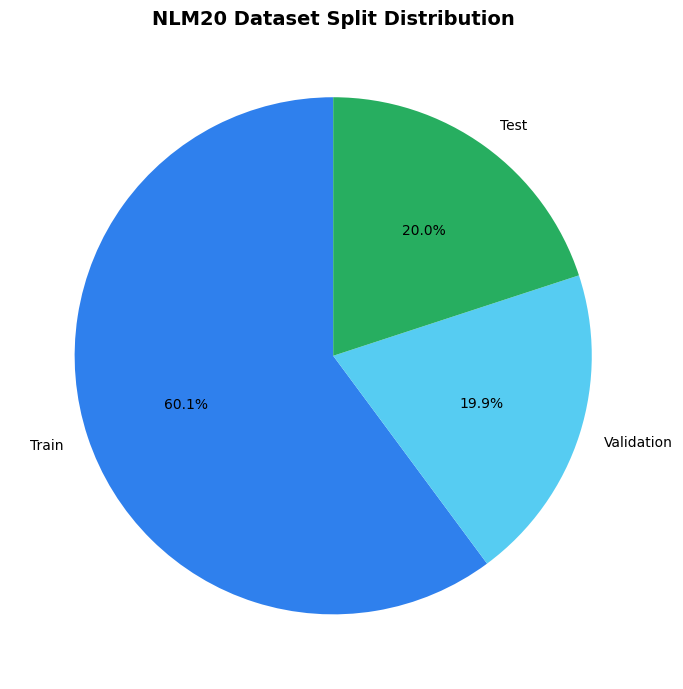

In [ ]:
# Medical-inspired colors for visualization
COLORS = MEDICAL_COLORS
# Visualize the dataset split proportions
split_counts = manifest['split'].value_counts().reindex(['train', 'valid', 'test'])
plt.figure(figsize=(7, 7))
plt.pie(split_counts.values, labels=['Train', 'Validation', 'Test'], autopct='%1.1f%%', startangle=90, colors=MEDICAL_COLORS)
plt.title('NLM20 Dataset Split Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### NDC Class Distribution by Split

In [ ]:
# Count the number of images for every NDC class in each split

distribution = pd.crosstab(
    manifest['ndc'],
    manifest['split']
)

distribution = distribution.reindex(
    columns=['train', 'valid', 'test'],
    fill_value=0
)

distribution['total'] = distribution.sum(axis=1)

display(distribution)

split,train,valid,test,total
ndc,,,,
00378-0208,602,199,200,1001
00378-3855,129,42,42,213
00591-0461,148,48,48,244
16729-0020,258,84,85,427
16729-0168,129,42,42,213
50111-0434,601,199,200,1000
53489-0156,600,200,200,1000
53746-0544,97,31,32,160
57664-0377,601,199,200,1000


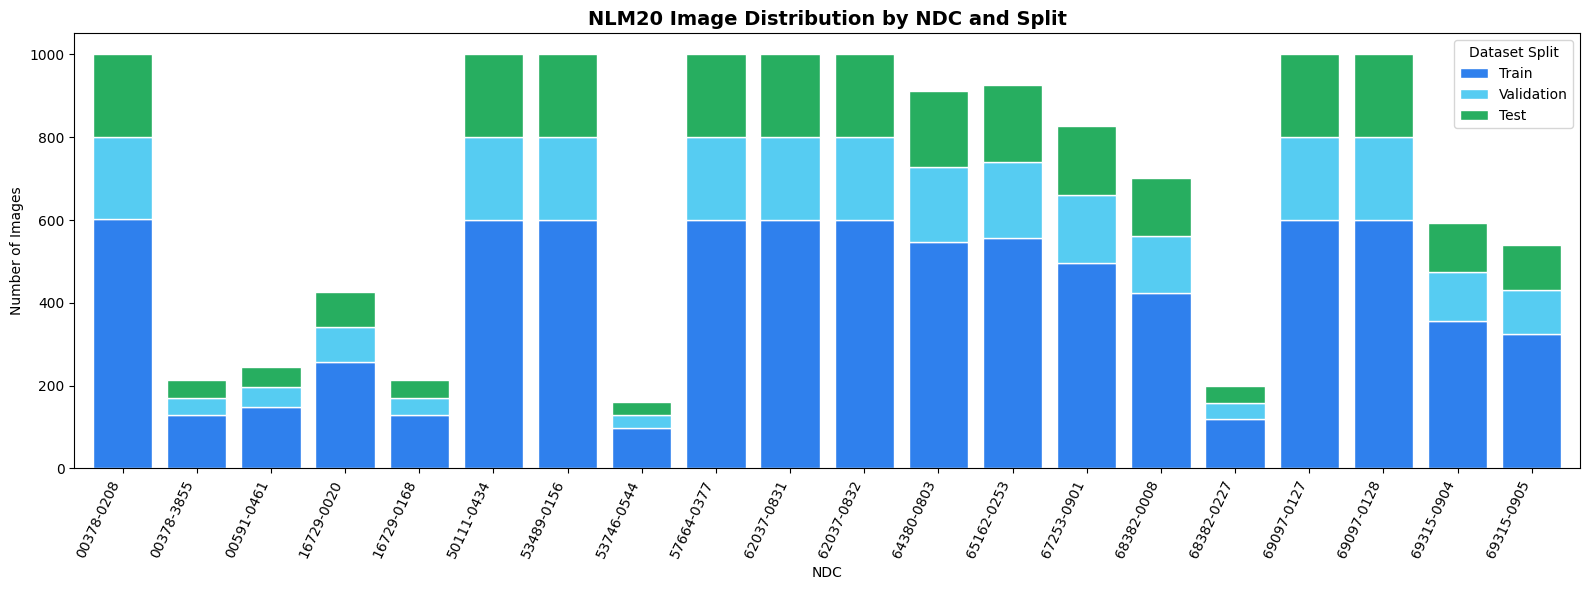

In [ ]:
# Visualize the class distribution across Train, Validation, and Test

plot_df = distribution[
    ['train', 'valid', 'test']
].copy()

ax = plot_df.plot(
    kind='bar',
    stacked=True,
    figsize=(16, 6),
    color=MEDICAL_COLORS,
    edgecolor='white',
    width=0.8
)

ax.set_title(
    'NLM20 Image Distribution by NDC and Split',
    fontsize=14,
    fontweight='bold'
)

ax.set_xlabel('NDC')
ax.set_ylabel('Number of Images')

plt.xticks(
    rotation=65,
    ha='right'
)

plt.legend(
    title='Dataset Split',
    labels=['Train', 'Validation', 'Test']
)

plt.tight_layout()
plt.show()

### Total Images per NDC

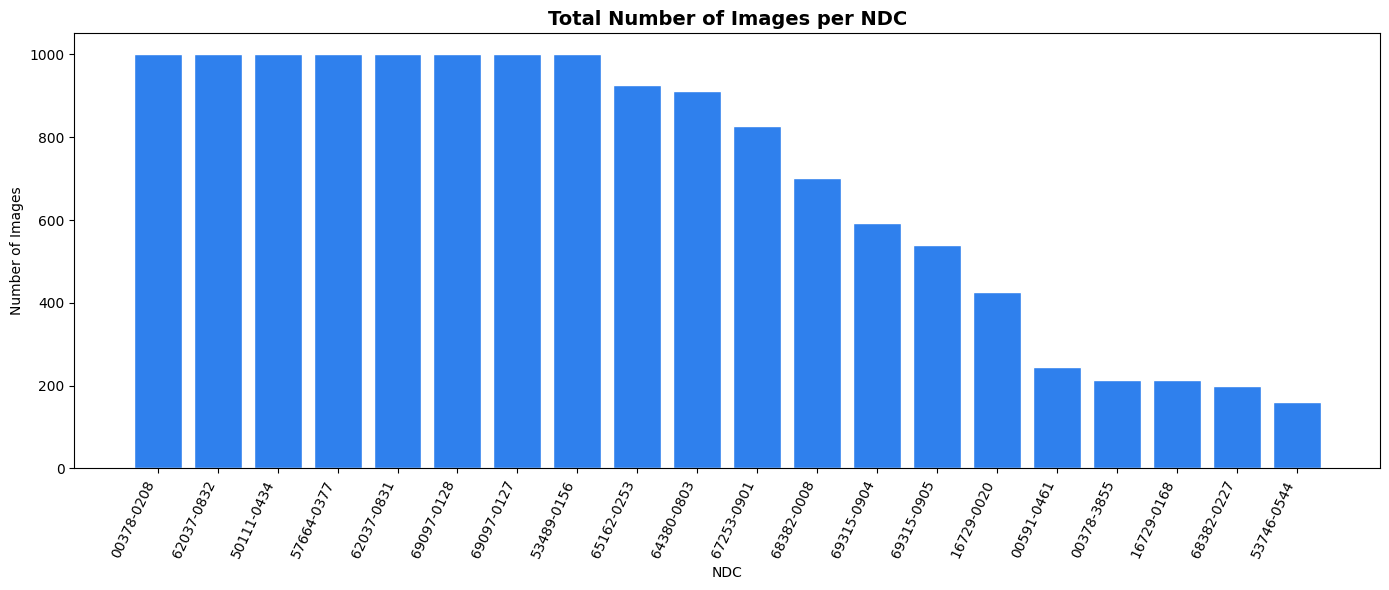

In [ ]:
# Visualize the total number of images in each NDC class

total_distribution = (
    distribution['total']
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 6))

plt.bar(
    total_distribution.index,
    total_distribution.values,
    color='#2F80ED',
    edgecolor='white'
)

plt.title(
    'Total Number of Images per NDC',
    fontsize=14,
    fontweight='bold'
)

plt.xlabel('NDC')
plt.ylabel('Number of Images')

plt.xticks(
    rotation=65,
    ha='right'
)

plt.tight_layout()
plt.show()

### Class Balance Summary

In [ ]:
# Measure the amount of class imbalance

min_class = distribution['total'].min()
max_class = distribution['total'].max()
mean_class = distribution['total'].mean()
median_class = distribution['total'].median()

imbalance_ratio = (
    max_class
    / min_class
)

print('Minimum class size:', min_class)
print('Maximum class size:', max_class)
print('Mean class size:', round(mean_class, 2))
print('Median class size:', round(median_class, 2))
print('Max/Min imbalance ratio:', round(imbalance_ratio, 2))

Minimum class size: 160
Maximum class size: 1001
Mean class size: 697.75
Median class size: 868.5
Max/Min imbalance ratio: 6.26


**EDA note:** The dataset shows moderate class imbalance. Therefore, model evaluation should include macro-averaged metrics in addition to overall accuracy.

## Add NDC-Level Medication Metadata

In [ ]:
# Published 20-class metadata table associated with the dataset
# This metadata is used for EDA and interpretation only.

metadata_rows = [
    ['00378-0208', 'Furosemide 20 mg oral tablet', 'Round', 'White', 'M2', 6, 602, 199, 200],
    ['00378-3855', 'Escitalopram 5 mg oral tablet', 'Round', 'White', 'M;EC5', 6, 129, 42, 42],
    ['00591-0461', 'Glipizide 10 mg oral tablet', 'Round', 'White', 'Watson;461', 10, 148, 48, 48],
    ['16729-0020', 'Pioglitazone 15 mg oral tablet', 'Round', 'White', 'P;15', 5, 258, 84, 85],
    ['16729-0168', 'Escitalopram 5 mg oral tablet', 'Round', 'White', '5', 5, 129, 42, 42],
    ['50111-0434', 'Trazodone hydrochloride 100 mg oral tablet', 'Round', 'White', 'PLIVA;434', 11, 601, 199, 200],
    ['53489-0156', 'Allopurinol 100 mg oral tablet', 'Round', 'White', 'MP;71', 10, 600, 200, 200],
    ['53746-0544', 'Primidone 50 mg oral tablet', 'Round', 'White', 'AN;44', 6, 97, 31, 32],
    ['57664-0377', 'Tramadol hydrochloride 50 mg oral tablet', 'Capsule', 'White', '377', 13, 601, 199, 200],
    ['62037-0831', 'Metoprolol succinate 50 mg extended-release tablet', 'Round', 'White', '831', 9, 600, 200, 200],
    ['62037-0832', 'Metoprolol succinate 100 mg extended-release tablet', 'Round', 'White', '832', 10, 601, 200, 200],
    ['64380-0803', 'Ranitidine 150 mg oral tablet (Strides Pharma)', 'Round', 'Brown', 'S;429', 10, 548, 181, 182],
    ['65162-0253', 'Ranitidine 150 mg oral tablet (Amneal Pharmaceuticals)', 'Round', 'Orange', 'IP;253', 9, 557, 184, 185],
    ['67253-0901', 'Alprazolam 0.5 mg oral tablet', 'Oval', 'Yellow', 'S901', 9, 497, 164, 165],
    ['68382-0008', 'Lamotrigine 100 mg oral tablet', 'Round', 'White', 'ZC;80', 10, 423, 139, 140],
    ['68382-0227', 'Amiodarone hydrochloride 200 mg oral tablet', 'Round', 'White', 'ZE;65', 10, 120, 39, 39],
    ['69097-0127', 'Amlodipine 5 mg oral tablet', 'Round', 'White', '127;C', 8, 600, 200, 200],
    ['69097-0128', 'Amlodipine 10 mg oral tablet', 'Round', 'White', '128;C', 8, 600, 200, 200],
    ['69315-0904', 'Lorazepam 0.5 mg oral tablet', 'Round', 'White', 'EP;904', 5, 357, 118, 118],
    ['69315-0905', 'Lorazepam 1 mg oral tablet', 'Round', 'White', 'EP;905;1', 7, 325, 107, 108]
]

meta = pd.DataFrame(
    metadata_rows,
    columns=[
        'ndc',
        'drug_name',
        'shape',
        'color',
        'imprint',
        'size_mm',
        'expected_train',
        'expected_valid',
        'expected_test'
    ]
)


# Add manufacturer/labeler information by NDC
manufacturer_map = {
    '00378-0208': 'Mylan Pharmaceuticals Inc.',
    '00378-3855': 'Mylan Pharmaceuticals Inc.',
    '00591-0461': 'Actavis Pharma, Inc.',
    '16729-0020': 'Accord Healthcare Inc.',
    '16729-0168': 'Accord Healthcare Inc.',
    '50111-0434': 'Teva Pharmaceuticals USA',
    '53489-0156': 'Sun Pharmaceutical Industries, Inc.',
    '53746-0544': 'Amneal Pharmaceuticals of New York LLC',
    '57664-0377': 'Sun Pharmaceutical Industries',
    '62037-0831': 'Actavis Pharma, Inc.',
    '62037-0832': 'Actavis Pharma, Inc.',
    '64380-0803': 'Strides Pharma Science Limited',
    '65162-0253': 'Amneal Pharmaceuticals LLC',
    '67253-0901': 'Par Pharmaceutical',
    '68382-0008': 'Zydus Pharmaceuticals USA Inc.',
    '68382-0227': 'Zydus Pharmaceuticals USA Inc.',
    '69097-0127': 'Cipla USA Inc.',
    '69097-0128': 'Cipla USA Inc.',
    '69315-0904': 'Leading Pharma, LLC',
    '69315-0905': 'Leading Pharma, LLC'
}

meta['manufacturer'] = meta['ndc'].map(manufacturer_map)

meta['expected_total'] = meta[
    [
        'expected_train',
        'expected_valid',
        'expected_test'
    ]
].sum(axis=1)

print(
    'Metadata classes:',
    meta['ndc'].nunique()
)

print(
    'Missing manufacturer/labeler:',
    meta['manufacturer'].isna().sum()
)

print(
    'Expected total images:',
    int(meta['expected_total'].sum())
)

display(meta)

Metadata classes: 20
Missing manufacturer/labeler: 0
Expected total images: 13955


,ndc,drug_name,shape,color,imprint,size_mm,expected_train,expected_valid,expected_test,manufacturer,expected_total
0,00378-0208,Furosemide 20 mg oral tablet,Round,White,M2,6,602,199,200,Mylan Pharmaceuticals Inc.,1001
1,00378-3855,Escitalopram 5 mg oral tablet,Round,White,M;EC5,6,129,42,42,Mylan Pharmaceuticals Inc.,213
2,00591-0461,Glipizide 10 mg oral tablet,Round,White,Watson;461,10,148,48,48,"Actavis Pharma, Inc.",244
3,16729-0020,Pioglitazone 15 mg oral tablet,Round,White,P;15,5,258,84,85,Accord Healthcare Inc.,427
4,16729-0168,Escitalopram 5 mg oral tablet,Round,White,5,5,129,42,42,Accord Healthcare Inc.,213
5,50111-0434,Trazodone hydrochloride 100 mg oral tablet,Round,White,PLIVA;434,11,601,199,200,Teva Pharmaceuticals USA,1000
6,53489-0156,Allopurinol 100 mg oral tablet,Round,White,MP;71,10,600,200,200,"Sun Pharmaceutical Industries, Inc.",1000
7,53746-0544,Primidone 50 mg oral tablet,Round,White,AN;44,6,97,31,32,Amneal Pharmaceuticals of New York LLC,160
8,57664-0377,Tramadol hydrochloride 50 mg oral tablet,Capsule,White,377,13,601,199,200,Sun Pharmaceutical Industries,1000
9,62037-0831,Metoprolol succinate 50 mg extended-release ta...,Round,White,831,9,600,200,200,"Actavis Pharma, Inc.",1000


### Merge Metadata with the Image Manifest

In [ ]:
# Remove metadata columns from any previous merge
# so this cell can be rerun safely without creating _x and _y columns.

metadata_columns = [
    'drug_name',
    'manufacturer',
    'shape',
    'color',
    'imprint',
    'size_mm',
    'expected_train',
    'expected_valid',
    'expected_test',
    'expected_total'
]

columns_to_remove = []

for column in manifest.columns:

    base_column = (
        column
        .replace('_x', '')
        .replace('_y', '')
    )

    if base_column in metadata_columns:

        columns_to_remove.append(column)

manifest = manifest.drop(
    columns=columns_to_remove,
    errors='ignore'
)

# Merge the image manifest with NDC-level metadata

manifest = manifest.merge(
    meta,
    on='ndc',
    how='left'
)

# Verify the merge

print(
    'Missing metadata:',
    manifest['drug_name'].isna().sum()
)

print(
    'Unique NDC classes:',
    manifest['ndc'].nunique()
)

print(
    'Unique medication names:',
    manifest['drug_name'].nunique()
)

display(
    manifest[
        [
            'ndc',
            'drug_name',
            'manufacturer',
            'shape',
            'color',
            'imprint',
            'size_mm',
            'split',
            'filename'
        ]
    ].head()
)

Missing metadata: 0
Unique NDC classes: 20
Unique medication names: 19


,ndc,drug_name,manufacturer,shape,color,imprint,size_mm,split,filename
0,00378-0208,Furosemide 20 mg oral tablet,Mylan Pharmaceuticals Inc.,Round,White,M2,6,train,101176.jpg
1,00378-0208,Furosemide 20 mg oral tablet,Mylan Pharmaceuticals Inc.,Round,White,M2,6,train,101177.jpg
2,00378-0208,Furosemide 20 mg oral tablet,Mylan Pharmaceuticals Inc.,Round,White,M2,6,train,103891.jpg
3,00378-0208,Furosemide 20 mg oral tablet,Mylan Pharmaceuticals Inc.,Round,White,M2,6,train,105082.jpg
4,00378-0208,Furosemide 20 mg oral tablet,Mylan Pharmaceuticals Inc.,Round,White,M2,6,train,105526.jpg


### Manufacturer / Labeler Summary


In [ ]:
# Review the manufacturer/labeler linked to each NDC

manufacturer_summary = (
    manifest[
        [
            'ndc',
            'drug_name',
            'manufacturer'
        ]
    ]
    .drop_duplicates()
    .sort_values('ndc')
    .reset_index(drop=True)
)

display(manufacturer_summary)

print(
    'Unique manufacturers/labelers:',
    manufacturer_summary['manufacturer'].nunique()
)

,ndc,drug_name,manufacturer
0,00378-0208,Furosemide 20 mg oral tablet,Mylan Pharmaceuticals Inc.
1,00378-3855,Escitalopram 5 mg oral tablet,Mylan Pharmaceuticals Inc.
2,00591-0461,Glipizide 10 mg oral tablet,"Actavis Pharma, Inc."
3,16729-0020,Pioglitazone 15 mg oral tablet,Accord Healthcare Inc.
4,16729-0168,Escitalopram 5 mg oral tablet,Accord Healthcare Inc.
5,50111-0434,Trazodone hydrochloride 100 mg oral tablet,Teva Pharmaceuticals USA
6,53489-0156,Allopurinol 100 mg oral tablet,"Sun Pharmaceutical Industries, Inc."
7,53746-0544,Primidone 50 mg oral tablet,Amneal Pharmaceuticals of New York LLC
8,57664-0377,Tramadol hydrochloride 50 mg oral tablet,Sun Pharmaceutical Industries
9,62037-0831,Metoprolol succinate 50 mg extended-release ta...,"Actavis Pharma, Inc."


Unique manufacturers/labelers: 13


### Check Medication Names Associated with More Than One NDC

In [ ]:
# Identify medication names that appear under more than one NDC class

duplicate_drug_names = (
    manifest[
        [
            'drug_name',
            'ndc'
        ]
    ]
    .drop_duplicates()
    .groupby('drug_name')['ndc']
    .agg(
        number_of_ndcs='nunique',
        ndc_list=lambda x: list(x)
    )
    .query(
        'number_of_ndcs > 1'
    )
)

display(duplicate_drug_names)

,number_of_ndcs,ndc_list
drug_name,,
Escitalopram 5 mg oral tablet,2,"[00378-3855, 16729-0168]"


The dataset contains **20 unique NDC classes but 19 unique medication names**, since **Escitalopram 5 mg oral tablet** appears under two distinct NDC products.

The model target remains the **20 NDC classes**, not the medication name.

### Sample Images

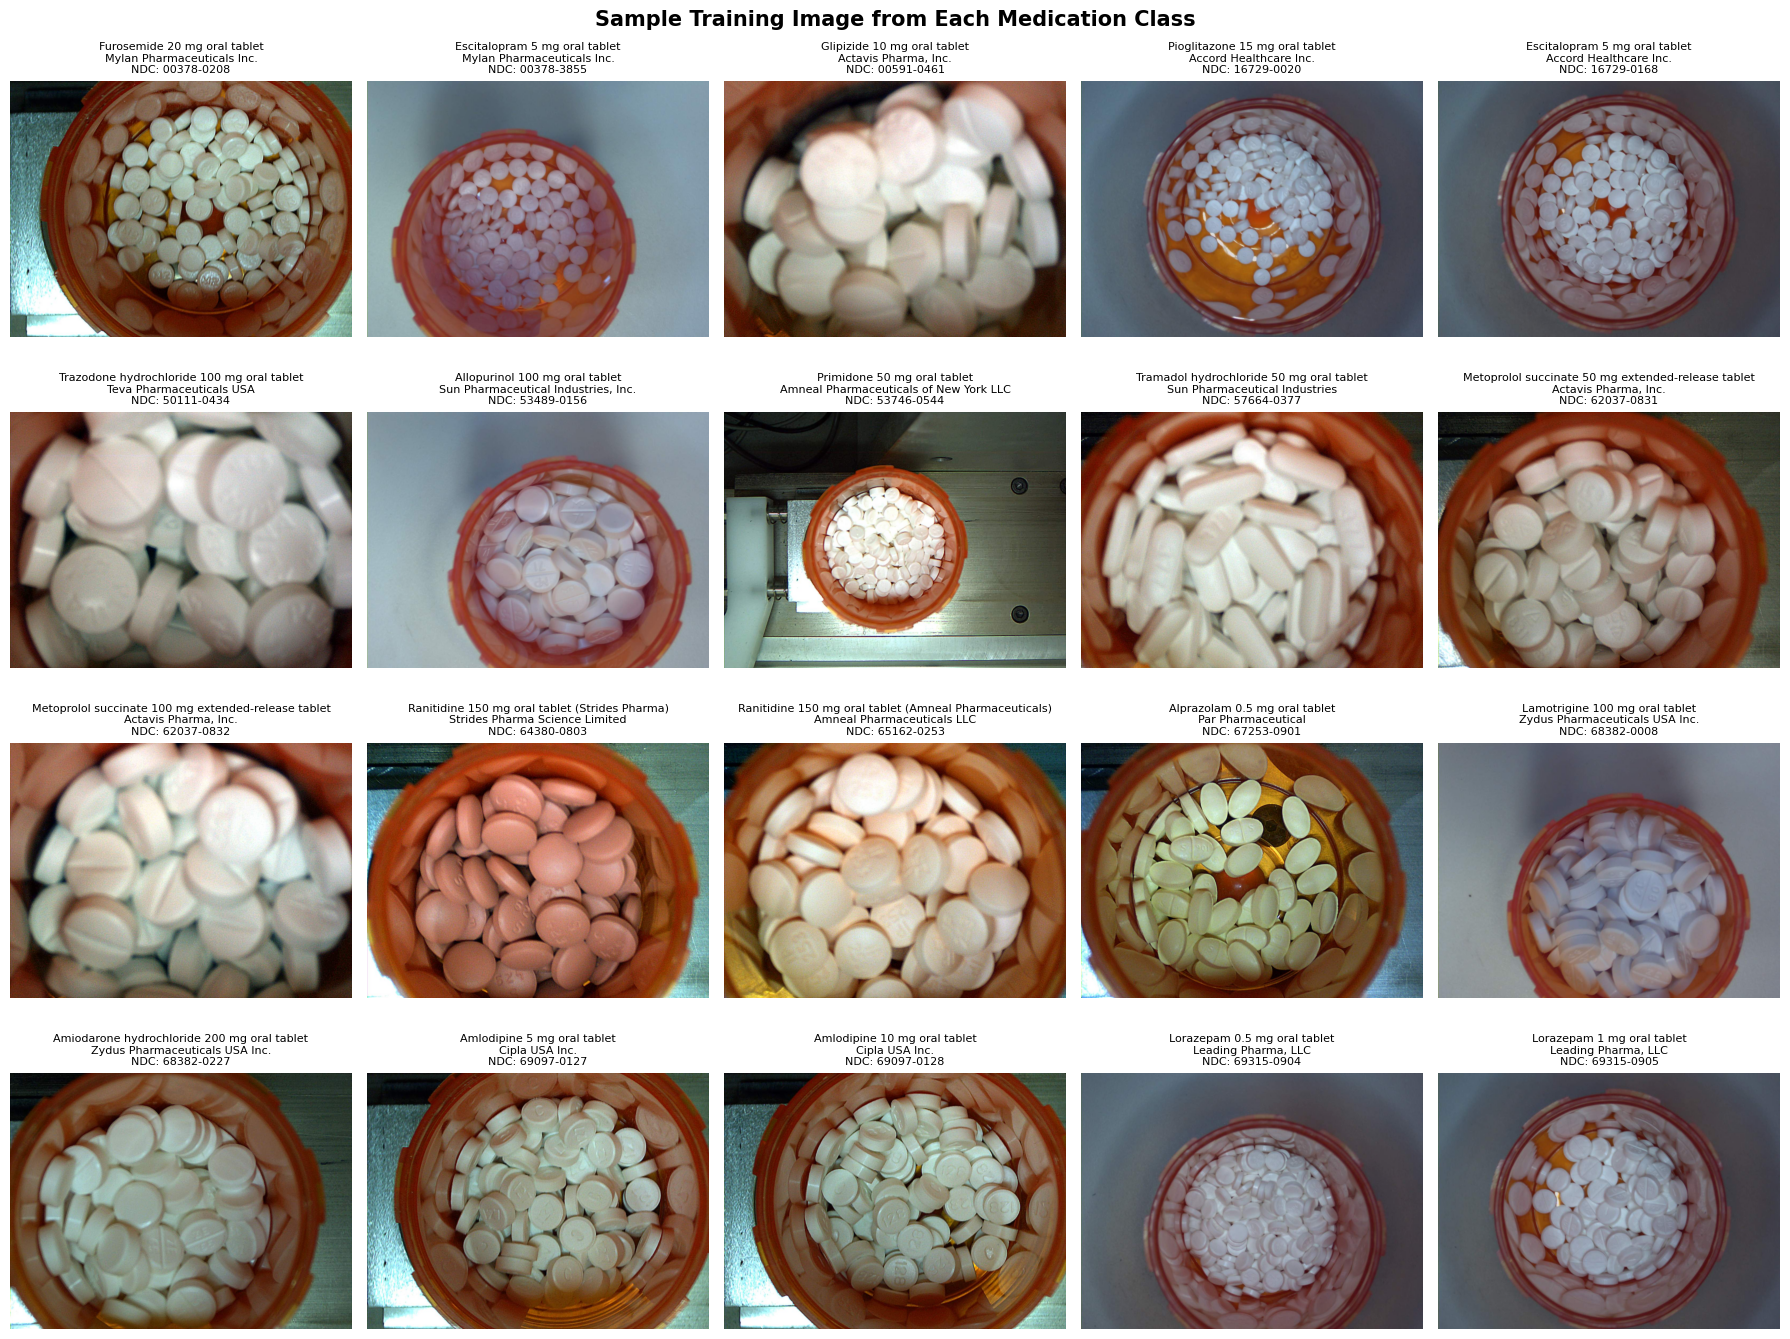

In [ ]:
# Display one sample training image from each NDC class

class_names = sorted(
    manifest['ndc'].unique()
)

sample_rows = []

for ndc in class_names:

    class_rows = manifest[
        (manifest['ndc'] == ndc)
        & (manifest['split'] == 'train')
    ]

    if len(class_rows) > 0:

        sample_rows.append(
            class_rows.sample(
                1,
                random_state=SEED
            ).iloc[0]
        )

fig, axes = plt.subplots(
    4,
    5,
    figsize=(18, 14)
)

axes = axes.flatten()

for ax, row in zip(
    axes,
    sample_rows
):

    image = Image.open(
        row['image_path']
    ).convert('RGB')

    ax.imshow(image)

    ax.set_title(
        f"{row['drug_name']}\n{row['manufacturer']}\nNDC: {row['ndc']}",
        fontsize=8
    )

    ax.axis('off')

plt.suptitle(
    'Sample Training Image from Each Medication Class',
    fontsize=15,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

## Inspect Image Size

In [ ]:
# Inspect a random sample instead of opening all 13,955 images from Google Drive.
# The full corruption/readability check was already completed in the previous EDA notebook.

sample_paths = manifest[
    'image_path'
].sample(
    n=min(100, len(manifest)),
    random_state=SEED
)

image_sizes = []

for image_path in sample_paths:

    with Image.open(image_path) as image:

        width, height = image.size

        image_sizes.append({
            'width': width,
            'height': height,
            'mode': image.mode
        })

image_sizes = pd.DataFrame(
    image_sizes
)

print('Sampled images:', len(image_sizes))

display(
    image_sizes[
        ['width', 'height']
    ].describe()
)

print('Most common image sizes:')

display(
    image_sizes[
        ['width', 'height']
    ]
    .value_counts()
    .head(10)
)

print('Image modes:')

display(
    image_sizes[
        'mode'
    ]
    .value_counts()
    .to_frame('count')
)

Sampled images: 100


,width,height
count,100.0,100.0
mean,1284.0,960.0
std,0.0,0.0
min,1284.0,960.0
25%,1284.0,960.0
50%,1284.0,960.0
75%,1284.0,960.0
max,1284.0,960.0


Most common image sizes:


,,count
width,height,
1284,960,100


Image modes:


,count
mode,
RGB,100


### Selected Model Input Size

We will use **224 × 224** pixels as the initial model input size.

This is a practical baseline for transfer-learning architectures such as MobileNetV2, ResNet50, and EfficientNetB0. The original images remain unchanged on Google Drive; resizing is applied only when the images are loaded.

The final model-specific preprocessing function will be selected in the modeling notebook.

## Preprocessing

### Load Official Train, Validation, and Test Sets

In [ ]:
# Load images directly from the official directory structure.
# Folder names are inferred as the 20 NDC class labels.

train_ds = image_dataset_from_directory(
    directory=TRAIN_DIR,
    labels='inferred',
    label_mode='int',
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    color_mode='rgb',
    shuffle=True,
    seed=SEED,
    interpolation='bilinear'
)

valid_ds = image_dataset_from_directory(
    directory=VALID_DIR,
    labels='inferred',
    label_mode='int',
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    color_mode='rgb',
    shuffle=False,
    interpolation='bilinear'
)

test_ds = image_dataset_from_directory(
    directory=TEST_DIR,
    labels='inferred',
    label_mode='int',
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    color_mode='rgb',
    shuffle=False,
    interpolation='bilinear'
)

class_names = train_ds.class_names

NUM_CLASSES = len(
    class_names
)

print(
    'Number of classes:',
    NUM_CLASSES
)

print(
    'Class names:'
)

print(
    class_names
)

Found 8393 files belonging to 20 classes.
Found 2776 files belonging to 20 classes.
Found 2786 files belonging to 20 classes.
Number of classes: 20
Class names:
['00378-0208', '00378-3855', '00591-0461', '16729-0020', '16729-0168', '50111-0434', '53489-0156', '53746-0544', '57664-0377', '62037-0831', '62037-0832', '64380-0803', '65162-0253', '67253-0901', '68382-0008', '68382-0227', '69097-0127', '69097-0128', '69315-0904', '69315-0905']


### Verify Class Order Across Splits

In [ ]:
# Confirm that the class-to-index mapping is identical across all splits

print(
    'Train classes == Validation classes:',
    train_ds.class_names == valid_ds.class_names
)

print(
    'Train classes == Test classes:',
    train_ds.class_names == test_ds.class_names
)

Train classes == Validation classes: True
Train classes == Test classes: True


### Visualize Images Before Normalization

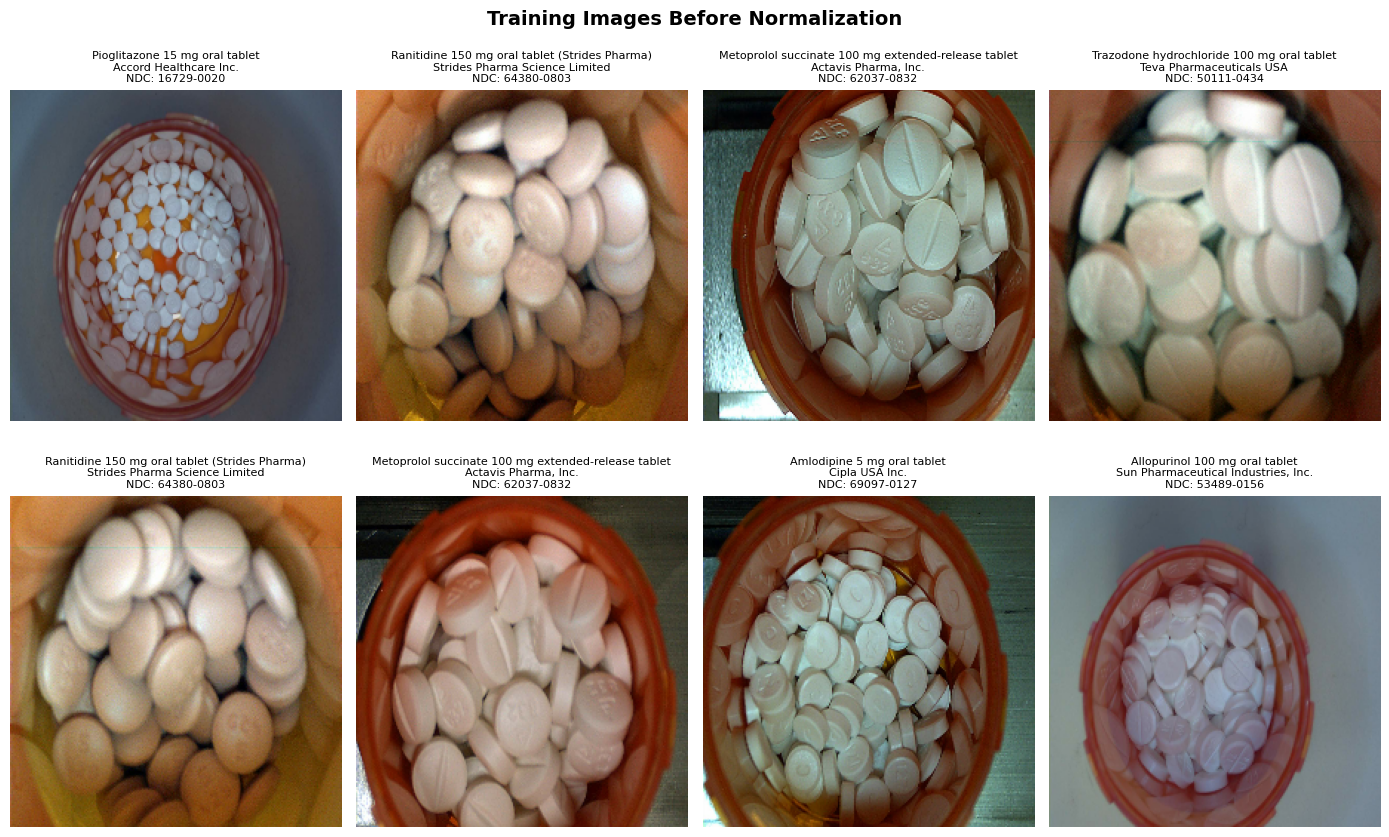

In [ ]:
# Create a lookup dictionary for visualization only

ndc_to_drug = dict(
    zip(
        meta['ndc'],
        meta['drug_name']
    )
)


ndc_to_manufacturer = dict(
    zip(
        meta['ndc'],
        meta['manufacturer']
    )
)

# Display a training batch before normalization

plt.figure(
    figsize=(14, 9)
)

for images, labels in train_ds.take(1):

    for i in range(
        min(
            8,
            len(images)
        )
    ):

        ax = plt.subplot(
            2,
            4,
            i + 1
        )

        plt.imshow(
            images[i]
            .numpy()
            .astype('uint8')
        )

        # Convert numeric class index back to NDC

        ndc = class_names[
            int(labels[i])
        ]

        # Use metadata only to display a readable medication name

        drug_name = ndc_to_drug[
            ndc
        ]

        manufacturer = ndc_to_manufacturer[
            ndc
        ]

        plt.title(
            f'{drug_name}\n{manufacturer}\nNDC: {ndc}',
            fontsize=8
        )

        plt.axis(
            'off'
        )

plt.suptitle(
    'Training Images Before Normalization',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

### Generic Normalization Check

The following `[0, 1]` normalization is used only to inspect the general preprocessing result in this notebook.

**Do not automatically use `train_ds_preprocessed` for transfer-learning training.** In the modeling notebook, each architecture should use its own recommended preprocessing function when required, such as `tf.keras.applications.mobilenet_v2.preprocess_input` for MobileNetV2.

In [ ]:
# Create a generic normalization layer for visual inspection

normalization_layer = tf.keras.layers.Rescaling(
    1.0 / 255.0
)

def preprocess_for_visual_check(
    image,
    label
):

    image = tf.cast(
        image,
        tf.float32
    )

    image = normalization_layer(
        image
    )

    return image, label

In [ ]:
# Apply generic normalization for preprocessing inspection only

train_ds_preprocessed = train_ds.map(
    preprocess_for_visual_check,
    num_parallel_calls=AUTOTUNE
)

valid_ds_preprocessed = valid_ds.map(
    preprocess_for_visual_check,
    num_parallel_calls=AUTOTUNE
)

test_ds_preprocessed = test_ds.map(
    preprocess_for_visual_check,
    num_parallel_calls=AUTOTUNE
)

### Check Preprocessed Batch

In [ ]:
# Verify shape, data type, and pixel range after generic normalization
for images, labels in train_ds_preprocessed.take(1):
    print('Image batch shape:', images.shape)
    print('Label batch shape:', labels.shape)
    print('Image dtype:', images.dtype)
    print('Minimum pixel value:', float(tf.reduce_min(images)))
    print('Maximum pixel value:', float(tf.reduce_max(images)))

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Image dtype: <dtype: 'float32'>
Minimum pixel value: 0.0
Maximum pixel value: 1.0


### Visualize Images After Resize and Generic Normalization

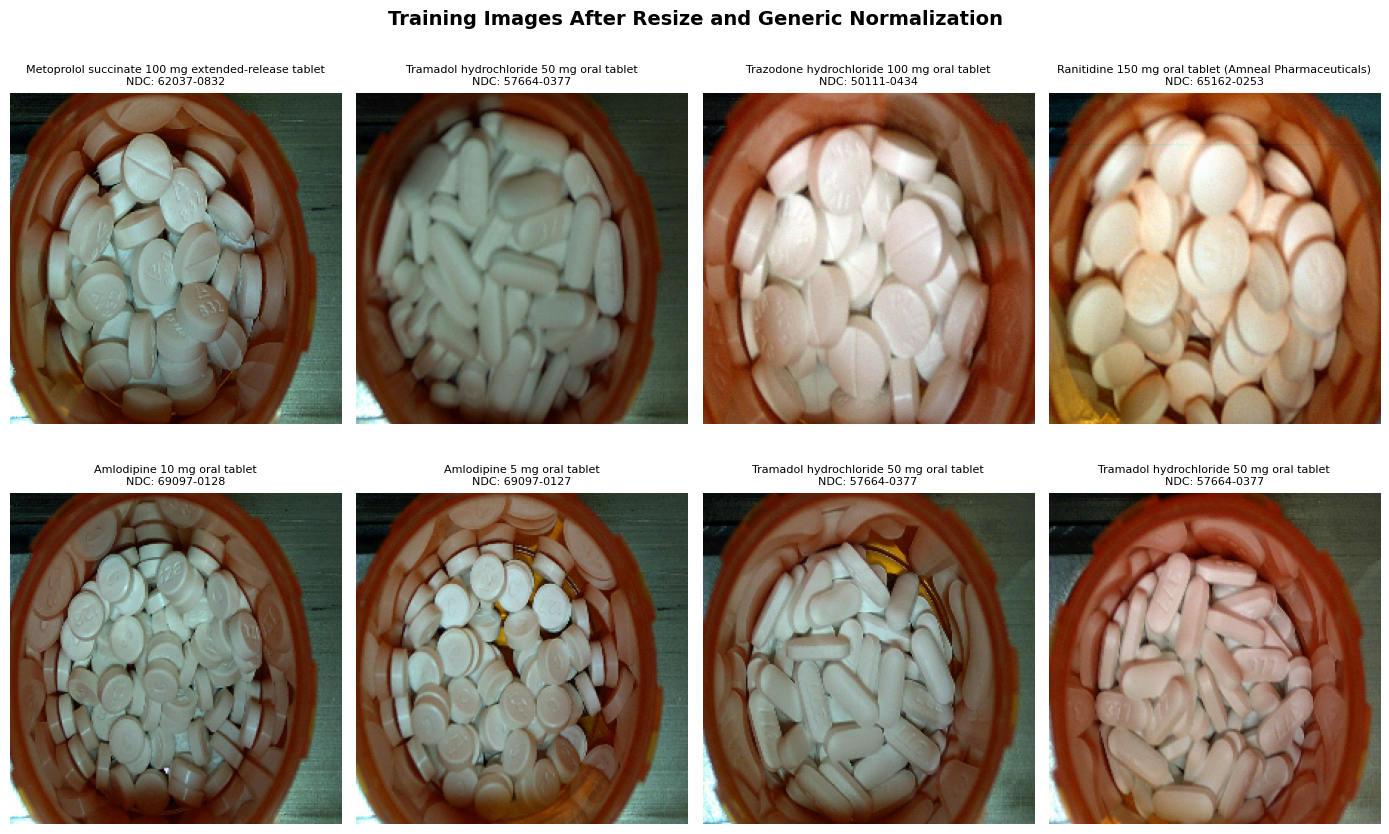

In [ ]:
# Display the same type of training batch after resize and generic normalization
plt.figure(figsize=(14, 9))
for images, labels in train_ds_preprocessed.take(1):
    for i in range(min(8, len(images))):
        ax = plt.subplot(2, 4, i + 1)
        plt.imshow(images[i].numpy())
        ndc = class_names[int(labels[i])]
        drug_name = ndc_to_drug[ndc]
        plt.title(f'{drug_name}\nNDC: {ndc}', fontsize=8)
        plt.axis('off')
plt.suptitle('Training Images After Resize and Generic Normalization', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Improve Input Pipeline Performance

In [ ]:
# Prefetch the original datasets for efficient downstream loading.
# Model-specific preprocessing will be added in the modeling notebook.

train_ds = train_ds.prefetch(
    AUTOTUNE
)

valid_ds = valid_ds.prefetch(
    AUTOTUNE
)

test_ds = test_ds.prefetch(
    AUTOTUNE
)

print(
    'Base image input pipeline is ready.'
)

Base image input pipeline is ready.


## Final Preprocessing Summary

In [ ]:
print('Dataset: Images of Pills Inside Medication Bottles')
print('Folder: NLM20')
print('Target: NDC')
print('Number of classes:', NUM_CLASSES)
print('Input image size:', IMG_SIZE)
print('Color mode: RGB')
print('Train shuffle: True')
print('Validation shuffle: False')
print('Test shuffle: False')
print('Official Train/Validation/Test split preserved: Yes')
print('Metadata used as model input: No')
print('Generic normalization checked: Yes')
print('Final model-specific preprocessing selected: Not yet')

Dataset: Images of Pills Inside Medication Bottles
Folder: NLM20
Target: NDC
Number of classes: 20
Input image size: (224, 224)
Color mode: RGB
Train shuffle: True
Validation shuffle: False
Test shuffle: False
Official Train/Validation/Test split preserved: Yes
Metadata used as model input: No
Generic normalization checked: Yes
Final model-specific preprocessing selected: Not yet
